In [1]:
import matplotlib.pyplot as plt

from phoxipy import PhoXiSensor
import datetime

time = datetime.datetime.now().isoformat()
print("Time: ", time)

p = PhoXiSensor("1703005")
p.start()


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Time:  2024-06-28T21:00:14.408562


True

In [2]:

frame = p.read()


Reading from PhoXi


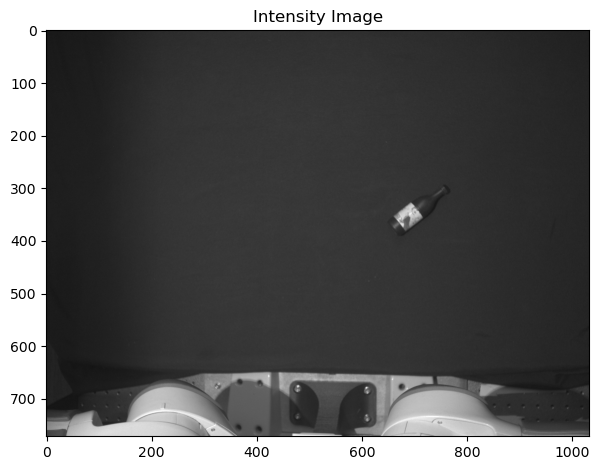

True

In [3]:

plt.title("Intensity Image")
plt.imshow(frame.color.data)
plt.tight_layout()
plt.show()
plt.imsave(f"intensity_image{time}.png", frame.color.data)
p.stop()


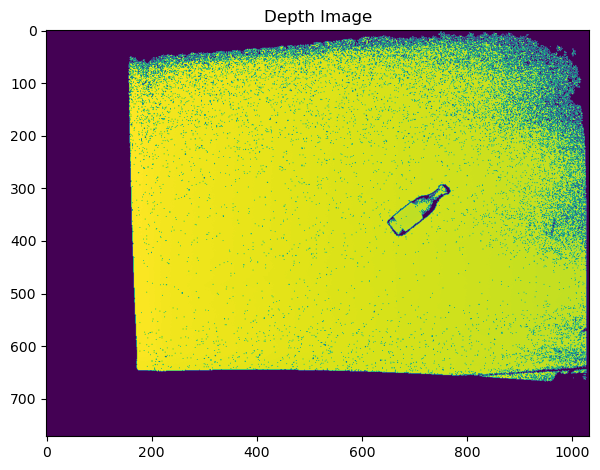

1.0574683
0.0


In [4]:
plt.title("Depth Image")
plt.imshow(frame.depth.data)
plt.tight_layout()
plt.show()
# plt.imsave(f"depth_image{time}.png", frame.depth.data)

print(frame.depth.data.max())
print(frame.depth.data.min())


In [5]:
from autolab_core import RigidTransform, PointCloud, RgbdImage, ColorImage, DepthImage
import numpy as np

# T_CAM_BASE = RigidTransform.load("/home/justinyu/multicable-decluttering/phoxipy/tools/phoxi_to_world_bww.tf").as_frames(from_frame="phoxi", to_frame="base_link")
#T_CAM_BASE = RigidTransform.load("/nfs/diskstation/calib/phoxi/phoxi_to_world.tf").as_frames(from_frame="phoxi",to_frame="base_link")
intr = p.create_intr(frame.color.data.shape[1], frame.color.data.shape[0])
print(intr.K)
# print(frame.depth.frame)
depth = DepthImage(frame.depth.data, frame.depth.frame)
# print(depth.data[get_largest_mask(filtered_areas).squeeze(0).cpu().numpy()])
# points_3d = intr.deproject(frame.depth)
points_3d = intr.deproject(depth) #[get_largest_mask(filtered_areas).squeeze(0).view(-1).cpu().numpy()]

points = np.array(points_3d.data)
points = points.transpose(1,0)
print(points.shape)
print(frame.color.data.shape)

color_flat = frame.color.data.reshape(-1,3)

def filter_points(points, colors = None, threshold = 0.05):
    """
    Filter points by mask
    """
    new_points = []
    new_color = []
    # print(points[0][0]**2 +points[0][1]**2 + points[0][2]**2)
    for i in range(points.shape[0]):
        dist_from_origin = points[i][0]**2 +points[i][1]**2 + points[i][2]**2
        # print(dist_from_origin)
        if dist_from_origin > threshold:
            new_points.append(points[i])
            if colors is not None:
                new_color.append(colors[i])
    return np.array(new_points), np.array(new_color)

# print(points_3d.data)
# print(points_3d.data.shape)

points, color = filter_points(points, color_flat)
# print(points.shape)
# print(color.shape)
# print(points)


[[1.105e+03 0.000e+00 5.160e+02]
 [0.000e+00 1.105e+03 3.860e+02]
 [0.000e+00 0.000e+00 1.000e+00]]
(796704, 3)
(772, 1032, 3)


In [6]:
T_CAM_BASE = RigidTransform.load("/home/justinyu/multicable-decluttering/phoxipy/tools/phoxi_to_world_bww.tf").as_frames(from_frame="phoxi", to_frame="base_link")
print(T_CAM_BASE)

# /home/justinyu/multicable-decluttering/phoxipy/tools/bww_chessboard.tf

print(T_CAM_BASE.rotation)
# x: -171.0595174, y: 0.2555704, z: 88.9342334

Tra: [ 0.363 -0.09   1.045]
 Rot: [[ 0.0037658 -0.999983   0.0044605]
 [-0.9938596 -0.0032494  0.1106006]
 [-0.1105842 -0.0048496 -0.993854 ]]
 Qtn: [-0.04080894  0.70726042 -0.70477668 -0.03751224]
 from phoxi to base_link
[[ 0.0037658 -0.999983   0.0044605]
 [-0.9938596 -0.0032494  0.1106006]
 [-0.1105842 -0.0048496 -0.993854 ]]


In [7]:
import open3d as o3d
import copy
T_CAM_BASE = RigidTransform.load("/home/justinyu/multicable-decluttering/phoxipy/tools/phoxi_to_world_bww.tf").as_frames(from_frame="phoxi", to_frame="base_link")
T_CHESSBOARD_BASE = RigidTransform.load("/home/justinyu/multicable-decluttering/phoxipy/tools/bww_chessboard.tf").as_frames(from_frame="phoxi", to_frame="base_link")

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(color/255)

pcd.transform(T_CAM_BASE.matrix)

origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1, origin=[0., 0., 0.])

mesh_chessboard = copy.deepcopy(origin)
# mesh_chessboard.translate((0.5, 0.000000, -0.003))
mesh_chessboard.transform(T_CHESSBOARD_BASE.matrix)

mesh_phoxi = copy.deepcopy(origin).transform(T_CAM_BASE.matrix)
# mesh_base.translate(T_CAM_BASE.translation)

# print(f'Center of mesh: {mesh.get_center()}')
# print(f'Center of mesh tx: {mesh_tx.get_center()}')

# frame_point = o3d.geometry.PointCloud()
# frame_point.points = o3d.utility.Vector3dVector(np.asarray([[0.02556368, -0.132598,  1.053]]))
# frame_point.colors = o3d.utility.Vector3dVector(np.asarray([[255,0,0]]))

o3d.visualization.draw_geometries([pcd, origin, mesh_phoxi, mesh_chessboard])


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
